
<div style="background:linear-gradient(135deg,#1a2a4a 0%,#2d4a7a 100%);padding:40px;border-radius:12px;margin-bottom:30px;">
  <h1 style="color:white;font-size:2.2em;margin:0 0 10px 0;">📦 Step 1 — Synthetic Data Generation</h1>
  <p style="color:#a8c4e0;font-size:1.1em;margin:0;">Supply Chain Planning System · Manufacturing Sector</p>
  <div style="margin-top:20px;display:flex;gap:15px;flex-wrap:wrap;">
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">🏭 Manufacturing</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">📅 104 weeks · 2 years</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">🤖 XGBoost ready</span>
    <span style="background:rgba(255,255,255,0.15);color:white;padding:5px 14px;border-radius:20px;font-size:.85em;">✅ Groups A·B·C·D·E</span>
  </div>
</div>



<div style="background:#f0f7ff;border-left:5px solid #2d6cdf;padding:20px 25px;border-radius:0 8px 8px 0;margin-bottom:25px;">
  <h2 style="color:#1a2a4a;margin-top:0;">🎯 Purpose of this notebook</h2>
  <p style="color:#333;line-height:1.7;">In a real-world project, we would work with historical ERP data. Since we are building this system from scratch, we <strong>generate realistic synthetic data</strong> that faithfully mimics 2 years of manufacturing operations.</p>
  <p style="color:#333;line-height:1.7;">Good synthetic data must embed real-world patterns:</p>
  <ul style="color:#333;line-height:2;">
    <li><strong>Trend</strong> — demand grows or declines over time</li>
    <li><strong>Seasonality</strong> — certain weeks are consistently stronger (e.g. end of quarter)</li>
    <li><strong>Noise</strong> — realistic random variation around the signal</li>
    <li><strong>Events</strong> — holidays reduce production, promotions spike orders</li>
    <li><strong>Cross-variable correlations</strong> — energy prices affect costs, supplier reliability affects lead times</li>
  </ul>
</div>



<div style="background:#fff8e1;border-left:5px solid #f5a623;padding:20px 25px;border-radius:0 8px 8px 0;margin-bottom:25px;">
  <h2 style="color:#1a2a4a;margin-top:0;">📐 What we will generate</h2>
  <table style="width:100%;border-collapse:collapse;font-size:.95em;">
    <tr style="background:#f5a623;color:white;">
      <th style="padding:10px 15px;text-align:left;">Dataset</th>
      <th style="padding:10px 15px;text-align:left;">Variable Group</th>
      <th style="padding:10px 15px;text-align:left;">Key Fields</th>
    </tr>
    <tr style="background:white;"><td style="padding:10px 15px;border-bottom:1px solid #eee;"><code>products.csv</code></td><td style="padding:10px 15px;border-bottom:1px solid #eee;">Catalogue</td><td style="padding:10px 15px;border-bottom:1px solid #eee;">name, category, cycle_time_h, defect_rate_pct, base_demand</td></tr>
    <tr style="background:#fafafa;"><td style="padding:10px 15px;border-bottom:1px solid #eee;"><code>orders.csv</code></td><td style="padding:10px 15px;border-bottom:1px solid #eee;">Group A — Demand</td><td style="padding:10px 15px;border-bottom:1px solid #eee;">ordered_qty, delivered_qty, returns, backlog</td></tr>
    <tr style="background:white;"><td style="padding:10px 15px;border-bottom:1px solid #eee;"><code>production.csv</code></td><td style="padding:10px 15px;border-bottom:1px solid #eee;">Group B — Production</td><td style="padding:10px 15px;border-bottom:1px solid #eee;">capacity_hours, maintenance_hours, produced_units, scrap_units</td></tr>
    <tr style="background:#fafafa;"><td style="padding:10px 15px;border-bottom:1px solid #eee;"><code>suppliers.csv</code></td><td style="padding:10px 15px;border-bottom:1px solid #eee;">Group C — Suppliers</td><td style="padding:10px 15px;border-bottom:1px solid #eee;">lead_time_real_d, reliability_pct, raw_material_price</td></tr>
    <tr style="background:white;"><td style="padding:10px 15px;border-bottom:1px solid #eee;"><code>externals.csv</code></td><td style="padding:10px 15px;border-bottom:1px solid #eee;">Group D — External</td><td style="padding:10px 15px;border-bottom:1px solid #eee;">pmi, energy_price_kwh, exchange_rate_eur_usd, is_holiday, plant_shutdown</td></tr>
    <tr style="background:#fafafa;"><td style="padding:10px 15px;"><code>customers.csv</code></td><td style="padding:10px 15px;">Group E — Customers</td><td style="padding:10px 15px;">framework_contract_units, has_promotion, has_launch, sector</td></tr>
  </table>
</div>


## 🔧 0. Setup & Imports

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, warnings
from IPython.display import display, HTML
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Simulation parameters ─────────────────────────────────────────────────────
N_WEEKS     = 104          # 2 years of weekly history
N_PRODUCTS  = 10
N_CUSTOMERS = 5
N_SUPPLIERS = 3
START_DATE  = datetime(2023, 1, 2)   # first Monday of 2023

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "data/raw"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Week index ────────────────────────────────────────────────────────────────
weeks = [START_DATE + timedelta(weeks=i) for i in range(N_WEEKS)]
week_index = list(range(N_WEEKS))

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor':   '#f8fafc',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE = ['#2d6cdf','#e84a5f','#2ecc71','#f5a623','#9b59b6',
           '#1abc9c','#e67e22','#3498db','#e74c3c','#95a5a6']

print("✅ Setup complete")
print(f"   {N_WEEKS} weeks ({N_WEEKS//52} years) · {N_PRODUCTS} products · "
      f"{N_CUSTOMERS} customers · {N_SUPPLIERS} suppliers")
print(f"   Date range: {weeks[0].strftime('%Y-%m-%d')} → {weeks[-1].strftime('%Y-%m-%d')}")


✅ Setup complete
   104 weeks (2 years) · 10 products · 5 customers · 3 suppliers
   Date range: 2023-01-02 → 2024-12-23



<div style="background:#f0fff4;border-left:5px solid #2ecc71;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">🏷️ Section 1 — Products catalogue</h2>
  <p style="color:#333;line-height:1.7;">We define <strong>10 industrial products</strong> across 3 categories. Each product carries its own production characteristics that will drive downstream generators.</p>
  <ul style="color:#333;line-height:2;">
    <li><strong>cycle_time_h</strong>: hours needed to produce one unit — determines throughput</li>
    <li><strong>defect_rate_pct</strong>: average % of units scrapped — affects real output</li>
    <li><strong>base_demand</strong>: mean weekly units ordered — anchor for the order generator</li>
    <li><strong>trend_weekly</strong>: small growth/decay applied each week (+0.5% to -0.3%)</li>
  </ul>
</div>


In [2]:

products_data = {
    'product_id':      list(range(1, N_PRODUCTS + 1)),
    'name': [
        'Hydraulic Pump A1', 'Steel Frame B2', 'Control Unit C3',
        'Sensor Array D4',   'Gear Assembly E5', 'Power Module F6',
        'Valve Block G7',    'Circuit Board H8', 'Drive Shaft I9',
        'Filter Housing J10'
    ],
    'category': [
        'Mechanical','Mechanical','Electronic',
        'Electronic','Mechanical','Electronic',
        'Mechanical','Electronic','Mechanical','Mechanical'
    ],
    'supplier_id': [1,1,2,2,3,2,1,3,3,1],      # which supplier provides raw material
    'cycle_time_h':    [4.5, 6.0, 2.0, 1.5, 5.0, 3.0, 4.0, 1.0, 7.0, 3.5],
    'defect_rate_pct': [2.1, 1.5, 3.8, 4.2, 1.8, 3.1, 2.5, 5.0, 1.2, 2.8],
    'base_demand':     [200, 150, 400, 500, 120, 300, 180, 600, 80,  250],
    'sale_price_eur':  [850, 420, 1200,680, 950, 780, 430, 310, 1100,290],
    'trend_weekly':    [0.003,-0.001,0.005,0.004,-0.002,0.003,0.001,0.005,-0.002,0.002],
}

df_products = pd.DataFrame(products_data)
print("✅ Products catalogue generated")
print(f"   {len(df_products)} products across {df_products['category'].nunique()} categories\n")
display(df_products.style
    .background_gradient(subset=['base_demand'], cmap='Blues')
    .background_gradient(subset=['defect_rate_pct'], cmap='Reds')
    .format({'sale_price_eur': '€{:.0f}', 'defect_rate_pct': '{:.1f}%',
             'trend_weekly': '{:+.3f}', 'cycle_time_h': '{:.1f}h'})
    .set_caption("Product Catalogue — 10 SKUs")
)


✅ Products catalogue generated
   10 products across 2 categories



,product_id,name,category,supplier_id,cycle_time_h,defect_rate_pct,base_demand,sale_price_eur,trend_weekly
0,1,Hydraulic Pump A1,Mechanical,1,4.5h,2.1%,200,€850,+0.003
1,2,Steel Frame B2,Mechanical,1,6.0h,1.5%,150,€420,-0.001
2,3,Control Unit C3,Electronic,2,2.0h,3.8%,400,€1200,+0.005
3,4,Sensor Array D4,Electronic,2,1.5h,4.2%,500,€680,+0.004
4,5,Gear Assembly E5,Mechanical,3,5.0h,1.8%,120,€950,-0.002
5,6,Power Module F6,Electronic,2,3.0h,3.1%,300,€780,+0.003
6,7,Valve Block G7,Mechanical,1,4.0h,2.5%,180,€430,+0.001
7,8,Circuit Board H8,Electronic,3,1.0h,5.0%,600,€310,+0.005
8,9,Drive Shaft I9,Mechanical,3,7.0h,1.2%,80,€1100,-0.002
9,10,Filter Housing J10,Mechanical,1,3.5h,2.8%,250,€290,+0.002



<div style="background:#f0f7ff;border-left:5px solid #2d6cdf;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">🌍 Section 2 — External variables (Group D)</h2>
  <p style="color:#333;line-height:1.7;">External macro variables are generated first because they will <strong>influence</strong> orders, production, and supplier behaviour downstream — this is how real correlations emerge naturally in the data.</p>
  <ul style="color:#333;line-height:2;">
    <li><strong>PMI</strong> (Purchasing Managers' Index): values above 50 indicate expansion. We simulate a realistic economic cycle with some randomness.</li>
    <li><strong>Energy price</strong>: mean-reverting process around a base of €0.12/kWh with occasional spikes.</li>
    <li><strong>EUR/USD exchange rate</strong>: random walk around 1.08 — relevant for imported raw materials.</li>
    <li><strong>Holidays</strong>: ~8 weeks/year with reduced activity (summer + Christmas + Easter).</li>
    <li><strong>Plant shutdowns</strong>: full stop weeks (2/year) — zero production.</li>
  </ul>
</div>


In [3]:

np.random.seed(SEED)

# ── PMI: economic cycle (sine wave + noise) ───────────────────────────────────
pmi_base   = 52 + 4 * np.sin(2 * np.pi * np.array(week_index) / 52)
pmi_values = np.clip(pmi_base + np.random.normal(0, 1.5, N_WEEKS), 44, 62)

# ── Energy price: mean-reverting + occasional spikes ─────────────────────────
energy = [0.12]
for i in range(1, N_WEEKS):
    shock  = np.random.choice([0, 0.015, -0.008], p=[0.92, 0.05, 0.03])
    new_e  = energy[-1] + 0.3 * (0.12 - energy[-1]) + np.random.normal(0, 0.003) + shock
    energy.append(max(0.07, min(0.22, new_e)))
energy = np.array(energy)

# ── EUR/USD: random walk ──────────────────────────────────────────────────────
fx = [1.08]
for i in range(1, N_WEEKS):
    fx.append(np.clip(fx[-1] + np.random.normal(0, 0.008), 0.95, 1.25))
fx = np.array(fx)

# ── Holidays: summer (weeks 27-31), Christmas (51-52, 1-2), Easter (~14-15) ──
holiday_weeks = set(range(27, 32)) | {51, 52, 1, 2, 14, 15}  # week-of-year
is_holiday    = np.array([1 if (START_DATE + timedelta(weeks=i)).isocalendar()[1]
                          in holiday_weeks else 0 for i in range(N_WEEKS)])

# ── Plant shutdowns: 2 fixed weeks per year ───────────────────────────────────
shutdown_weeks = {30, 82}  # absolute week index
plant_shutdown = np.array([1 if i in shutdown_weeks else 0 for i in range(N_WEEKS)])

df_externals = pd.DataFrame({
    'week':           weeks,
    'week_index':     week_index,
    'pmi':            np.round(pmi_values, 2),
    'energy_price_kwh': np.round(energy, 4),
    'exchange_rate_eur_usd': np.round(fx, 4),
    'is_holiday':     is_holiday,
    'plant_shutdown': plant_shutdown,
    'week_of_year':   [d.isocalendar()[1] for d in weeks],
    'quarter':        [((d.month - 1) // 3) + 1 for d in weeks],
})

print("✅ External variables generated")
print(f"   PMI range:    {pmi_values.min():.1f} – {pmi_values.max():.1f}")
print(f"   Energy range: €{energy.min():.3f} – €{energy.max():.3f} /kWh")
print(f"   Holiday weeks: {is_holiday.sum()} · Shutdowns: {plant_shutdown.sum()}")
display(df_externals.head(6))


✅ External variables generated
   PMI range:    45.2 – 58.0
   Energy range: €0.114 – €0.147 /kWh
   Holiday weeks: 22 · Shutdowns: 2


,week,week_index,pmi,energy_price_kwh,exchange_rate_eur_usd,is_holiday,plant_shutdown,week_of_year,quarter
0,2023-01-02,0,52.75,0.1200,1.0800,1,0,1,1
1,2023-01-09,1,52.27,0.1356,1.0772,1,0,2,1
2,2023-01-16,2,53.93,0.1249,1.0848,0,0,3,1
3,2023-01-23,3,55.70,0.1234,1.0964,0,0,4,1
4,2023-01-30,4,53.51,0.1173,1.0993,0,0,5,1
5,2023-02-06,5,53.92,0.1184,1.1039,0,0,6,1


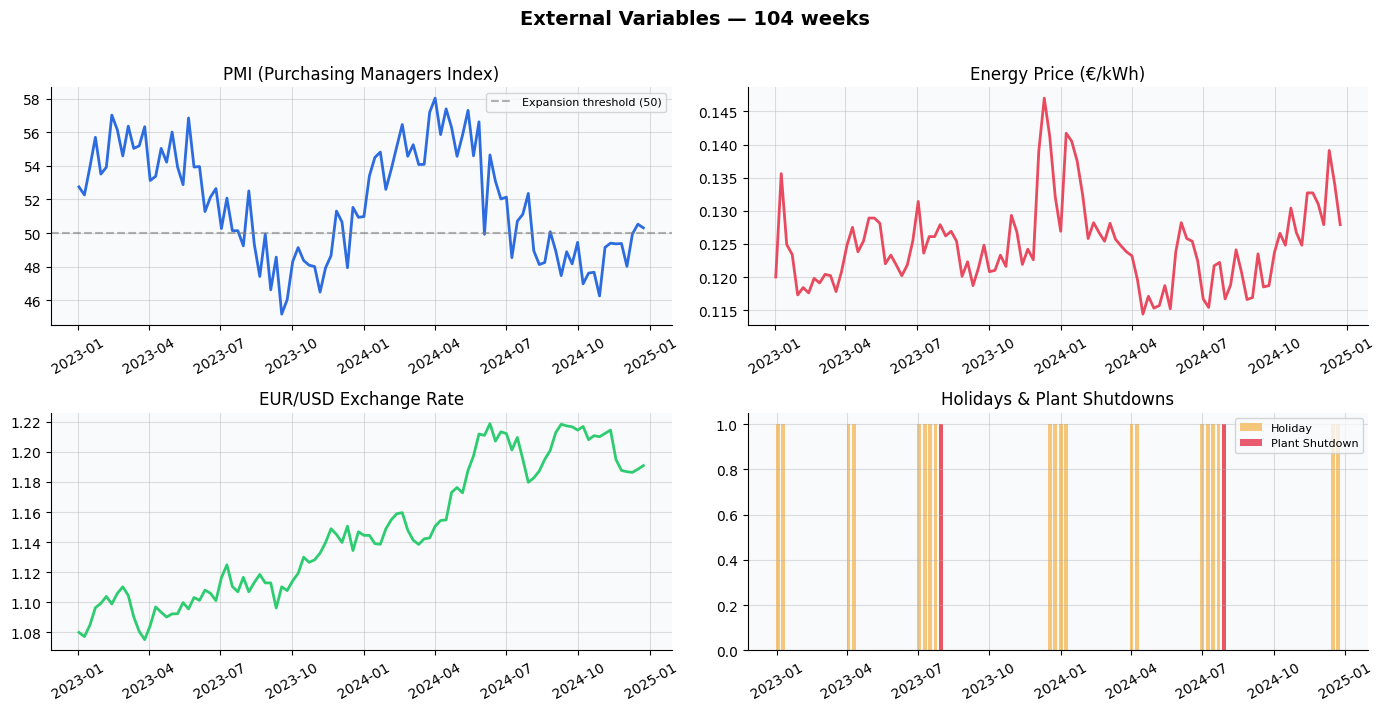

✅ Chart saved


In [4]:

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("External Variables — 104 weeks", fontsize=14, fontweight='bold', y=1.01)

axes[0,0].plot(df_externals['week'], df_externals['pmi'], color=PALETTE[0], lw=2)
axes[0,0].axhline(50, color='gray', ls='--', alpha=0.6, label='Expansion threshold (50)')
axes[0,0].set_title('PMI (Purchasing Managers Index)'); axes[0,0].legend(fontsize=8)

axes[0,1].plot(df_externals['week'], df_externals['energy_price_kwh'], color=PALETTE[1], lw=2)
axes[0,1].set_title('Energy Price (€/kWh)')

axes[1,0].plot(df_externals['week'], df_externals['exchange_rate_eur_usd'], color=PALETTE[2], lw=2)
axes[1,0].set_title('EUR/USD Exchange Rate')

# Holiday & shutdown markers
hol_idx = df_externals[df_externals['is_holiday'] == 1]['week']
shu_idx = df_externals[df_externals['plant_shutdown'] == 1]['week']
axes[1,1].bar(df_externals['week'], df_externals['is_holiday'],
              color=PALETTE[3], alpha=0.6, label='Holiday', width=5)
axes[1,1].bar(df_externals['week'], df_externals['plant_shutdown'],
              color=PALETTE[1], alpha=0.9, label='Plant Shutdown', width=5)
axes[1,1].set_title('Holidays & Plant Shutdowns'); axes[1,1].legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/raw/externals_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Chart saved")



<div style="background:#fdf0ff;border-left:5px solid #9b59b6;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">🚚 Section 3 — Suppliers (Group C)</h2>
  <p style="color:#333;line-height:1.7;">Supplier variables are generated <strong>per supplier per week</strong>. Key design choices:</p>
  <ul style="color:#333;line-height:2;">
    <li><strong>Lead time</strong> degrades slightly during holiday weeks and energy price spikes (real-world correlation).</li>
    <li><strong>Reliability</strong> follows a beta distribution — most weeks are good, but there are realistic bad streaks.</li>
    <li><strong>Raw material price</strong> is correlated with the EUR/USD rate — if dollar strengthens, imports cost more.</li>
  </ul>
</div>


In [5]:

np.random.seed(SEED + 1)

supplier_profiles = {
    1: {'name': 'MetalWorks GmbH',    'country': 'DE', 'base_lt': 7,  'reliability': 0.93, 'base_price': 45.0},
    2: {'name': 'TechParts Co.',      'country': 'TW', 'base_lt': 21, 'reliability': 0.85, 'base_price': 28.0},
    3: {'name': 'EuroComponents SL',  'country': 'ES', 'base_lt': 10, 'reliability': 0.90, 'base_price': 38.0},
}

supplier_rows = []
for sup_id, prof in supplier_profiles.items():
    for i, week in enumerate(weeks):
        # Lead time: base + holiday penalty + energy spike penalty
        energy_shock = max(0, df_externals.loc[i, 'energy_price_kwh'] - 0.15) * 20
        holiday_pen  = 3 if df_externals.loc[i, 'is_holiday'] else 0
        lt_noise     = np.random.normal(0, 1.5)
        lead_time    = max(3, prof['base_lt'] + holiday_pen + energy_shock + lt_noise)

        # Reliability: beta distribution, dips during shutdowns
        rel_base  = prof['reliability'] - 0.10 * df_externals.loc[i, 'plant_shutdown']
        rel_base  = np.clip(rel_base, 0.5, 0.99)
        reliability = np.clip(np.random.beta(rel_base * 20, (1 - rel_base) * 20), 0.5, 1.0)

        # Raw material price: correlated with FX + trend + noise
        fx_effect   = (df_externals.loc[i, 'exchange_rate_eur_usd'] - 1.08) * prof['base_price'] * 0.5
        trend_effect = i * 0.02 * (1 if sup_id == 2 else 0.3)
        rm_price    = max(5, prof['base_price'] + fx_effect + trend_effect + np.random.normal(0, 1.2))

        supplier_rows.append({
            'supplier_id':        sup_id,
            'supplier_name':      prof['name'],
            'country':            prof['country'],
            'week':               week,
            'week_index':         i,
            'lead_time_real_d':   round(lead_time, 1),
            'reliability_pct':    round(reliability * 100, 1),
            'raw_material_price': round(rm_price, 2),
        })

df_suppliers = pd.DataFrame(supplier_rows)
print("✅ Supplier data generated")
print(f"   {len(df_suppliers)} rows ({N_SUPPLIERS} suppliers × {N_WEEKS} weeks)")
print("\nMean lead times per supplier:")
print(df_suppliers.groupby('supplier_name')['lead_time_real_d'].agg(['mean','min','max']).round(1))


✅ Supplier data generated
   312 rows (3 suppliers × 104 weeks)

Mean lead times per supplier:
                   mean   min   max
supplier_name                      
EuroComponents SL  10.8   5.2  15.0
MetalWorks GmbH     7.6   3.8  13.3
TechParts Co.      21.6  18.0  26.3



<div style="background:#fff0f0;border-left:5px solid #e84a5f;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">🏢 Section 4 — Customers (Group E)</h2>
  <p style="color:#333;line-height:1.7;">Customers define committed demand via <strong>framework contracts</strong> and introduce demand spikes through <strong>promotions</strong> and <strong>product launches</strong>. These are binary events that the ML model must learn to detect and use.</p>
</div>


In [6]:

np.random.seed(SEED + 2)

customer_profiles = [
    {'id':1,'name':'AutoGroup AG',     'sector':'Automotive',  'contract_base':300, 'promo_freq':0.06},
    {'id':2,'name':'BuildCorp SA',     'sector':'Construction','contract_base':200, 'promo_freq':0.04},
    {'id':3,'name':'EnergyTech Ltd',   'sector':'Energy',      'contract_base':250, 'promo_freq':0.05},
    {'id':4,'name':'MediDevice GmbH',  'sector':'Medical',     'contract_base':150, 'promo_freq':0.03},
    {'id':5,'name':'AeroSystems Inc',  'sector':'Aerospace',   'contract_base':180, 'promo_freq':0.04},
]

customer_rows = []
for cp in customer_profiles:
    for i, week in enumerate(weeks):
        # Framework contract: grows slightly over time, dips on holidays
        contract = cp['contract_base'] * (1 + 0.002 * i) * (0.5 if df_externals.loc[i,'is_holiday'] else 1)

        # Promotions: random binary events, never during shutdowns
        has_promo  = 0 if df_externals.loc[i,'plant_shutdown'] else int(np.random.random() < cp['promo_freq'])

        # Launches: ~2-3 per year, last 3-4 weeks
        has_launch = int(np.random.random() < 0.025) if not df_externals.loc[i,'plant_shutdown'] else 0

        customer_rows.append({
            'customer_id':             cp['id'],
            'customer_name':           cp['name'],
            'sector':                  cp['sector'],
            'week':                    week,
            'week_index':              i,
            'framework_contract_units': round(contract),
            'has_promotion':           has_promo,
            'has_launch':              has_launch,
        })

df_customers = pd.DataFrame(customer_rows)
print("✅ Customer data generated")
print(f"   {len(df_customers)} rows ({N_CUSTOMERS} customers × {N_WEEKS} weeks)")
print(f"   Total promotion weeks: {df_customers['has_promotion'].sum()}")
print(f"   Total launch weeks:    {df_customers['has_launch'].sum()}")


✅ Customer data generated
   520 rows (5 customers × 104 weeks)
   Total promotion weeks: 20
   Total launch weeks:    7



<div style="background:#f0fff4;border-left:5px solid #2ecc71;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">📦 Section 5 — Orders (Group A)</h2>
  <p style="color:#333;line-height:1.7;">This is the most important dataset — it contains the <strong>target variable</strong> (<code>ordered_qty</code>) that XGBoost will learn to predict. We build it as a realistic function of all previously generated variables.</p>
  <p style="color:#333;line-height:1.7;"><strong>Demand signal formula:</strong></p>
  <div style="background:#1e1e1e;color:#a8ff78;padding:15px 20px;border-radius:8px;font-family:monospace;font-size:.9em;">
    demand = base_demand<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; × (1 + trend × week)<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; × seasonal_factor (sine wave)<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; × pmi_factor<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; × (1.35 if promotion else 1.0)<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; × (1.50 if launch else 1.0)<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; × (0.30 if holiday else 1.0)<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; × (0.00 if shutdown else 1.0)<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; + gaussian_noise
  </div>
</div>


In [7]:

np.random.seed(SEED + 3)

order_rows = []

for _, prod in df_products.iterrows():
    backlog = 0
    for i, week in enumerate(weeks):
        ext = df_externals.iloc[i]

        # Shutdown: zero demand
        if ext['plant_shutdown']:
            ordered_qty = 0
            delivered_qty = 0
            returns = 0
            backlog = min(backlog, backlog * 0.5)   # partial carryover
        else:
            # ── Demand components ────────────────────────────────────────────
            trend_factor    = 1 + prod['trend_weekly'] * i
            seasonal_factor = 1 + 0.20 * np.sin(2 * np.pi * i / 52 + np.pi/4)
            pmi_factor      = 0.7 + 0.3 * ((ext['pmi'] - 44) / (62 - 44))
            holiday_factor  = 0.30 if ext['is_holiday'] else 1.0

            # Customer event effects (averaged across customers)
            week_customers  = df_customers[df_customers['week_index'] == i]
            promo_boost     = 1.35 if week_customers['has_promotion'].any() else 1.0
            launch_boost    = 1.50 if week_customers['has_launch'].any() else 1.0

            base = prod['base_demand']
            signal = (base * trend_factor * seasonal_factor * pmi_factor
                      * holiday_factor * promo_boost * launch_boost)
            noise  = np.random.normal(0, base * 0.08)
            ordered_qty = max(0, round(signal + noise))

            # Delivered: limited by capacity (random fulfillment rate 85-100%)
            fill_rate     = np.random.uniform(0.85, 1.0)
            delivered_qty = min(ordered_qty, round(ordered_qty * fill_rate))

            # Returns: ~2-3% of delivered
            returns = round(delivered_qty * np.random.uniform(0.01, 0.04))

            # Backlog accumulates if not fully fulfilled
            backlog = max(0, backlog + (ordered_qty - delivered_qty))

        order_rows.append({
            'product_id':   prod['product_id'],
            'week':         week,
            'week_index':   i,
            'ordered_qty':  ordered_qty,
            'delivered_qty': delivered_qty,
            'returns':      returns,
            'backlog':      round(backlog),
        })

df_orders = pd.DataFrame(order_rows)
print("✅ Orders generated")
print(f"   {len(df_orders)} rows ({N_PRODUCTS} products × {N_WEEKS} weeks)")
print(f"   Total ordered:   {df_orders['ordered_qty'].sum():,} units")
print(f"   Mean fill rate:  {(df_orders['delivered_qty'].sum()/df_orders['ordered_qty'].replace(0,np.nan).sum())*100:.1f}%")
print(f"   Total backlog:   {df_orders['backlog'].sum():,} units")


✅ Orders generated
   1040 rows (10 products × 104 weeks)
   Total ordered:   257,686 units
   Mean fill rate:  92.2%
   Total backlog:   702,526 units


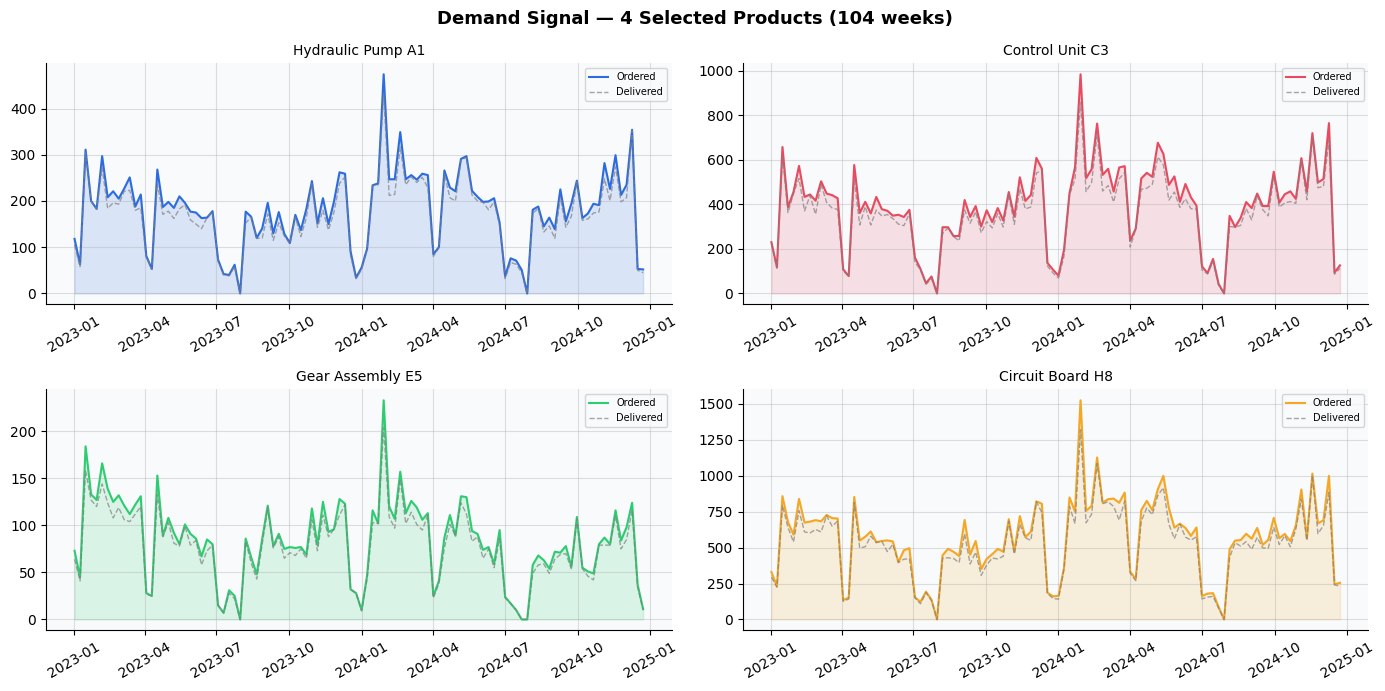

In [8]:

# ── Plot demand for 4 products ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Demand Signal — 4 Selected Products (104 weeks)", fontsize=13, fontweight='bold')

for ax, pid, color in zip(axes.flat, [1, 3, 5, 8], PALETTE):
    sub = df_orders[df_orders['product_id'] == pid]
    prod_name = df_products[df_products['product_id'] == pid]['name'].values[0]
    ax.fill_between(sub['week'], sub['ordered_qty'], alpha=0.15, color=color)
    ax.plot(sub['week'], sub['ordered_qty'], color=color, lw=1.5, label='Ordered')
    ax.plot(sub['week'], sub['delivered_qty'], color='gray', lw=1, ls='--', alpha=0.7, label='Delivered')
    ax.set_title(prod_name, fontsize=10)
    ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/raw/orders_overview.png', dpi=120, bbox_inches='tight')
plt.show()



<div style="background:#fff8e1;border-left:5px solid #f5a623;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">🏭 Section 6 — Production (Group B)</h2>
  <p style="color:#333;line-height:1.7;">Production data tracks the actual manufacturing output. Key relationships embedded:</p>
  <ul style="color:#333;line-height:2;">
    <li><strong>Capacity</strong>: 168 hours/week maximum. Maintenance and holidays reduce it.</li>
    <li><strong>Utilisation</strong>: driven by demand — higher orders push utilisation up.</li>
    <li><strong>Scrap</strong>: proportional to each product's defect rate, slightly higher under high utilisation (rush = more errors).</li>
  </ul>
</div>


In [9]:

np.random.seed(SEED + 4)

production_rows = []
MAX_CAPACITY_H = 168   # hours per week (24×7)

for _, prod in df_products.iterrows():
    for i, week in enumerate(weeks):
        ext = df_externals.iloc[i]

        if ext['plant_shutdown']:
            production_rows.append({
                'product_id': prod['product_id'], 'week': week, 'week_index': i,
                'capacity_hours': 0, 'maintenance_hours': MAX_CAPACITY_H,
                'produced_units': 0, 'scrap_units': 0, 'utilisation_pct': 0,
            })
            continue

        # Maintenance: higher on holidays, random spikes
        maint_base  = 10 if ext['is_holiday'] else 5
        maint_spike = np.random.choice([0, 20, 40], p=[0.90, 0.07, 0.03])
        maint_hours = min(MAX_CAPACITY_H, maint_base + maint_spike + np.random.uniform(0, 5))
        capacity    = MAX_CAPACITY_H - maint_hours

        # Units producible from available capacity
        max_producible = capacity / prod['cycle_time_h']

        # Actual demand pull from orders
        demand = df_orders[(df_orders['product_id'] == prod['product_id']) &
                           (df_orders['week_index'] == i)]['ordered_qty'].values[0]
        target = min(max_producible, demand * 1.05)   # slight overproduction buffer

        utilisation = min(1.0, target / max_producible) if max_producible > 0 else 0
        produced    = round(target * np.random.uniform(0.95, 1.0))

        # Scrap increases with high utilisation (rushing)
        defect_adj  = prod['defect_rate_pct'] * (1 + 0.3 * utilisation)
        scrap       = round(produced * (defect_adj / 100))

        production_rows.append({
            'product_id':      prod['product_id'],
            'week':            week,
            'week_index':      i,
            'capacity_hours':  round(capacity, 1),
            'maintenance_hours': round(maint_hours, 1),
            'produced_units':  produced,
            'scrap_units':     scrap,
            'utilisation_pct': round(utilisation * 100, 1),
        })

df_production = pd.DataFrame(production_rows)
print("✅ Production data generated")
print(f"   {len(df_production)} rows")
print(f"   Mean utilisation:  {df_production['utilisation_pct'].mean():.1f}%")
print(f"   Total scrap units: {df_production['scrap_units'].sum():,}")
print(f"   Shutdown weeks:    {(df_production['produced_units']==0).sum()} rows with zero output")


✅ Production data generated
   1040 rows
   Mean utilisation:  96.9%
   Total scrap units: 2,755
   Shutdown weeks:    21 rows with zero output



<div style="background:#f0f7ff;border-left:5px solid #2d6cdf;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">💾 Section 7 — Save & validate datasets</h2>
  <p style="color:#333;line-height:1.7;">We save all datasets to <code>data/raw/</code> as CSV files and run a basic <strong>data quality check</strong> — null counts, row counts, and a coherence check between orders and production.</p>
</div>


In [10]:

# ── Save all datasets ─────────────────────────────────────────────────────────
datasets = {
    'products.csv':   df_products,
    'orders.csv':     df_orders,
    'production.csv': df_production,
    'suppliers.csv':  df_suppliers,
    'externals.csv':  df_externals,
    'customers.csv':  df_customers,
}

for fname, df in datasets.items():
    path = f"{OUTPUT_DIR}/{fname}"
    df.to_csv(path, index=False)
    print(f"💾 Saved {fname:20s} → {len(df):>6,} rows · {df.shape[1]} cols · {os.path.getsize(path)/1024:.1f} KB")


💾 Saved products.csv         →     10 rows · 9 cols · 0.6 KB
💾 Saved orders.csv           →  1,040 rows · 7 cols · 31.3 KB
💾 Saved production.csv       →  1,040 rows · 8 cols · 39.2 KB
💾 Saved suppliers.csv        →    312 rows · 8 cols · 15.8 KB
💾 Saved externals.csv        →    104 rows · 9 cols · 4.5 KB
💾 Saved customers.csv        →    520 rows · 8 cols · 25.1 KB


In [11]:

# ── Data quality report ───────────────────────────────────────────────────────
print("\n" + "="*60)
print("  DATA QUALITY REPORT")
print("="*60)

all_ok = True
for fname, df in datasets.items():
    nulls = df.isnull().sum().sum()
    status = "✅" if nulls == 0 else "⚠️ "
    if nulls > 0: all_ok = False
    print(f"{status} {fname:22s}  rows={len(df):>6,}  nulls={nulls:>3}  dtypes OK={all(df.dtypes != object or col=='name' for col in df.columns)}")

print("="*60)
print(f"\n{'✅ All datasets clean — no null values found!' if all_ok else '⚠️  Some nulls detected, review above.'}")

# ── Coherence check: total ordered vs total produced ──────────────────────────
total_ordered  = df_orders['ordered_qty'].sum()
total_produced = df_production['produced_units'].sum()
ratio = total_produced / total_ordered
print(f"\nCoherence check:")
print(f"   Total ordered:  {total_ordered:>10,} units")
print(f"   Total produced: {total_produced:>10,} units")
print(f"   Ratio:          {ratio:.3f}  {'✅ (expected ~1.0±0.15)' if 0.85 < ratio < 1.15 else '⚠️  Unexpected ratio'}")



  DATA QUALITY REPORT


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().


<div style="background:#f0fff4;border-left:5px solid #2ecc71;padding:20px 25px;border-radius:0 8px 8px 0;margin:25px 0;">
  <h2 style="color:#1a2a4a;margin-top:0;">🔍 Section 8 — Cross-variable correlation insights</h2>
  <p style="color:#333;line-height:1.7;">Before moving to feature engineering, we verify that the correlations we embedded in the generators are actually present in the data. This is a <strong>sanity check</strong>: if the signals aren't visible here, the model won't learn them either.</p>
</div>


In [ ]:

# ── Build a weekly aggregate for correlation analysis ─────────────────────────
agg_orders = df_orders.groupby('week_index')['ordered_qty'].sum().reset_index()
agg_prod   = df_production.groupby('week_index')['utilisation_pct'].mean().reset_index()
agg_sup    = df_suppliers.groupby('week_index')['lead_time_real_d'].mean().reset_index()

corr_df = (df_externals[['week_index','pmi','energy_price_kwh','exchange_rate_eur_usd','is_holiday','plant_shutdown']]
           .merge(agg_orders, on='week_index')
           .merge(agg_prod,   on='week_index')
           .merge(agg_sup,    on='week_index'))

corr_matrix = corr_df.drop(columns='week_index').corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Cross-variable Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('data/raw/correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey correlations to note:")
for col in ['pmi','is_holiday','plant_shutdown','energy_price_kwh']:
    val = corr_matrix.loc['ordered_qty', col]
    direction = "📈" if val > 0.1 else ("📉" if val < -0.1 else "➡️ ")
    print(f"  {direction} ordered_qty ↔ {col:30s}  r = {val:+.3f}")



<div style="background:linear-gradient(135deg,#1a2a4a 0%,#2d4a7a 100%);padding:30px 35px;border-radius:12px;margin-top:30px;">
  <h2 style="color:white;margin-top:0;">✅ Step 1 complete — What we built</h2>
  <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:20px;margin-top:20px;">
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">DATASETS</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">6 CSVs</div>
      <div style="color:#a8c4e0;font-size:.8em;">products · orders · production<br>suppliers · externals · customers</div>
    </div>
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">TOTAL ROWS</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">~4,500+</div>
      <div style="color:#a8c4e0;font-size:.8em;">104 weeks × 10 products<br>× 3–5 entities</div>
    </div>
    <div style="background:rgba(255,255,255,0.1);padding:15px;border-radius:8px;">
      <div style="color:#a8c4e0;font-size:.85em;margin-bottom:5px;">NEXT STEP</div>
      <div style="color:white;font-size:1.4em;font-weight:bold;">Notebook 02</div>
      <div style="color:#a8c4e0;font-size:.8em;">Feature engineering<br>Lags · rolling stats · encoding</div>
    </div>
  </div>
  <p style="color:#a8c4e0;margin-top:20px;font-size:.9em;">📁 All files saved to <code style="background:rgba(255,255,255,0.15);padding:2px 6px;border-radius:4px;">data/raw/</code></p>
</div>
